#Covid-19 Trend Analysis

#1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

sns.set(style="whitegrid")

#2.Load Dataset

In [2]:
df = pd.read_csv("covid_19_clean_complete.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


#3.Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (49068, 10)

Column Names:
['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB

Statistical Summary:


,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


#4.Data Quality Check

In [4]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values
Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

Duplicate Rows
0


#5.Data Cleaning


Convert Date column


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

Fill missing Province/State

In [6]:
df['Province/State'].fillna("Unknown", inplace=True)

/tmp/ipykernel_322/1251359420.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Province/State'].fillna("Unknown", inplace=True)


#6.Global COVID Summary

In [7]:
global_cases = df[['Confirmed','Deaths','Recovered','Active']].sum()

print("Global COVID Summary")

print(global_cases)

Global COVID Summary
Confirmed    828508482
Deaths        43384903
Recovered    388408229
Active       396715350
dtype: int64


#7.Cases Over Time

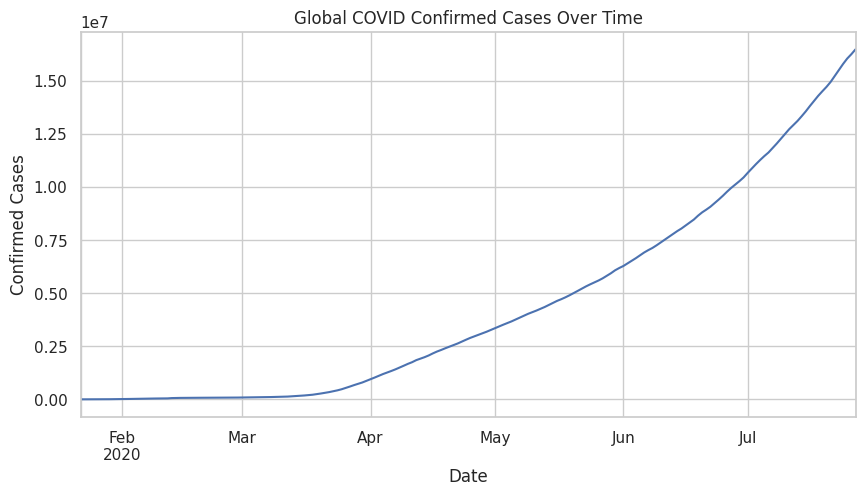

In [8]:
daily_cases = df.groupby('Date')['Confirmed'].sum()

plt.figure(figsize=(10,5))

daily_cases.plot()

plt.title("Global COVID Confirmed Cases Over Time")

plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.show()

#8.Visualization

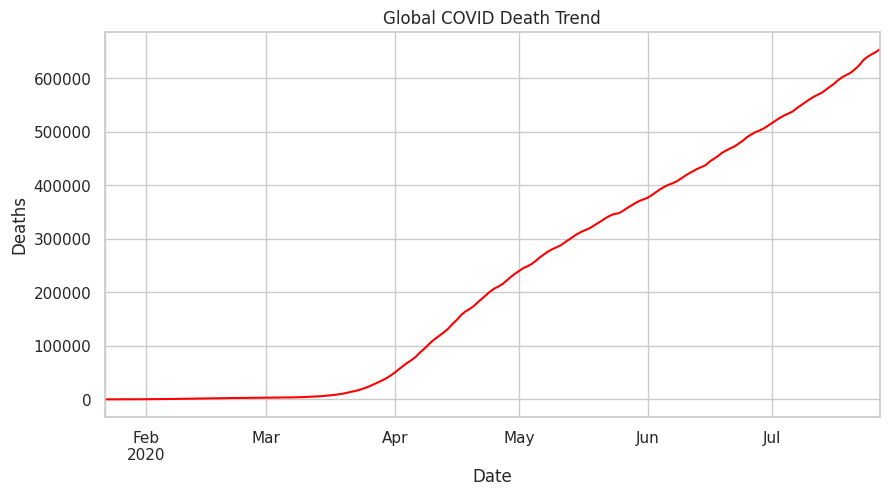

In [9]:
#Death Trend
daily_deaths = df.groupby('Date')['Deaths'].sum()

plt.figure(figsize=(10,5))

daily_deaths.plot(color='red')

plt.title("Global COVID Death Trend")

plt.xlabel("Date")
plt.ylabel("Deaths")

plt.show()

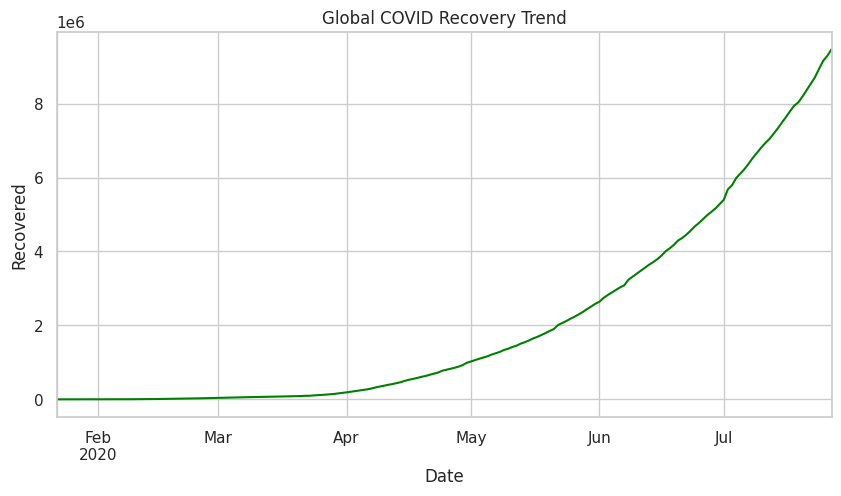

In [10]:
#Recovery Trend
daily_recovered = df.groupby('Date')['Recovered'].sum()

plt.figure(figsize=(10,5))

daily_recovered.plot(color='green')

plt.title("Global COVID Recovery Trend")

plt.xlabel("Date")
plt.ylabel("Recovered")

plt.show()

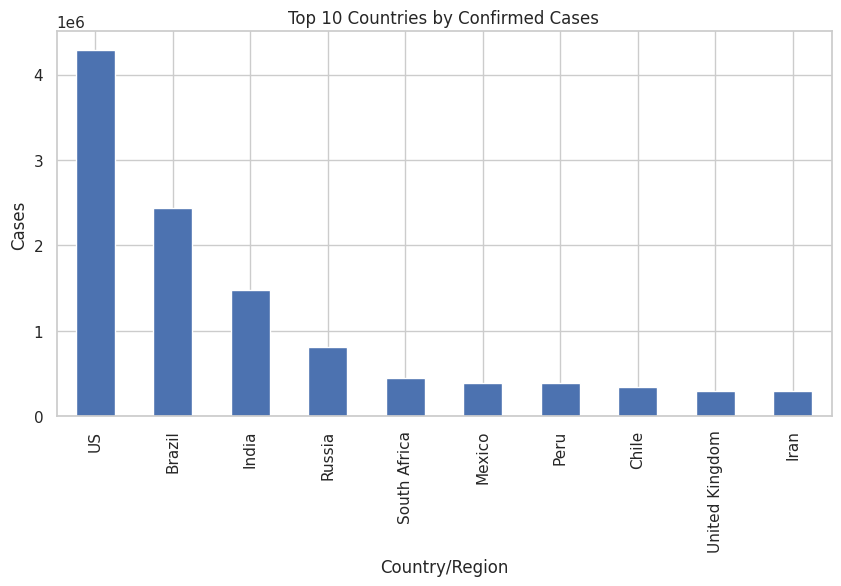

In [11]:
#Top 10 Affected Countries
country_cases = df.groupby('Country/Region')['Confirmed'].max()

top_countries = country_cases.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Confirmed Cases")

plt.ylabel("Cases")

plt.show()

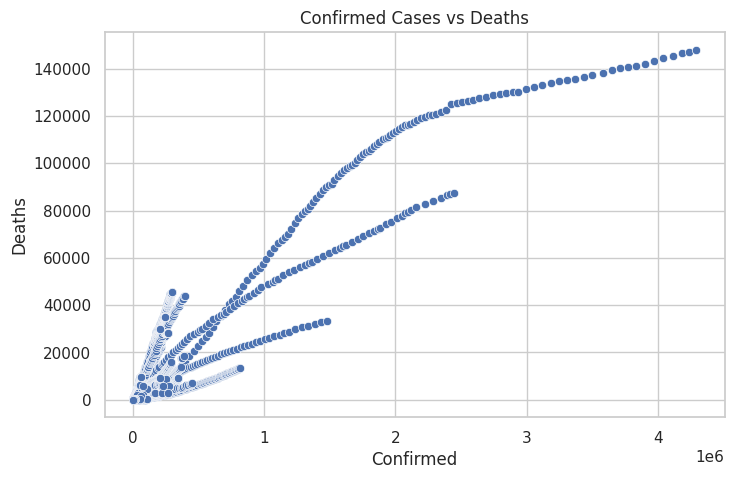

In [12]:
#Confirmed vs Deaths
plt.figure(figsize=(8,5))

sns.scatterplot(x='Confirmed', y='Deaths', data=df)

plt.title("Confirmed Cases vs Deaths")

plt.show()

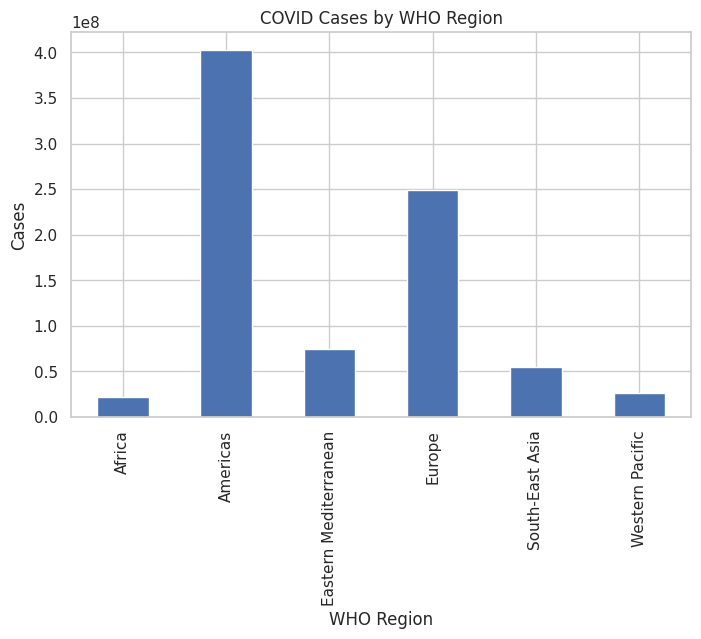

In [13]:
#WHO Region Distribution
region_cases = df.groupby('WHO Region')['Confirmed'].sum()

plt.figure(figsize=(8,5))

region_cases.plot(kind='bar')

plt.title("COVID Cases by WHO Region")

plt.ylabel("Cases")

plt.show()

Correlation Analysis

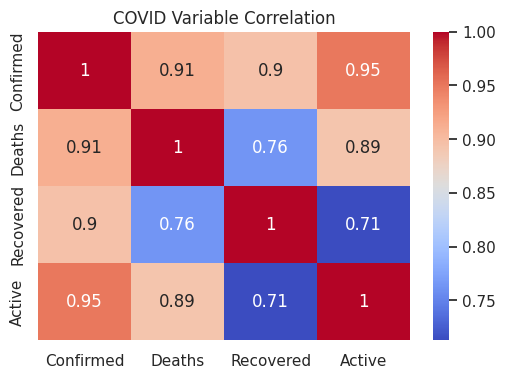

In [14]:
plt.figure(figsize=(6,4))

sns.heatmap(df[['Confirmed','Deaths','Recovered','Active']].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("COVID Variable Correlation")

plt.show()

#Automated Healthcare Report

In [15]:
print("===== COVID HEALTHCARE REPORT =====")

print("\nTotal Confirmed Cases:", df['Confirmed'].sum())

print("\nTotal Deaths:", df['Deaths'].sum())

print("\nTotal Recovered:", df['Recovered'].sum())

print("\nMost Affected Country:")
print(df.groupby('Country/Region')['Confirmed'].max().idxmax())

===== COVID HEALTHCARE REPORT =====

Total Confirmed Cases: 828508482

Total Deaths: 43384903

Total Recovered: 388408229

Most Affected Country:
US


## Results and Observations

The COVID-19 dataset contains global records of confirmed cases, deaths, recovered cases, and active cases across multiple countries and regions. The dataset was explored and cleaned to ensure accurate analysis.

Initial data quality checks confirmed that the dataset does not contain significant missing values or duplicate records. The date column was converted into datetime format to enable time-based analysis of the pandemic's progression.

Time-series analysis revealed a continuous increase in confirmed COVID-19 cases across the observed time period. Death trends follow a similar pattern but at a lower scale compared to confirmed cases.

Recovery trends indicate that a large portion of infected individuals recovered over time, demonstrating improvements in healthcare response and treatment strategies during the pandemic.

Country-level analysis showed that a small number of countries contributed a significant share of global cases. Visualization of the top affected countries highlights the uneven distribution of the pandemic across regions.

## Key Insights

Several important insights were identified during the analysis:

1. The number of confirmed COVID-19 cases increased rapidly over time, indicating the global spread of the virus.

2. Death trends show a consistent relationship with confirmed cases, meaning higher infection rates generally resulted in higher mortality.

3. Recovery trends demonstrate the effectiveness of healthcare interventions and improvements in treatment methods.

4. The pandemic affected countries differently, with some countries experiencing significantly higher case counts than others.

5. WHO regional analysis shows that certain regions experienced higher concentrations of cases, indicating geographic differences in the spread of the virus.

## Conclusion

This project analyzed global COVID-19 data to understand the progression and impact of the pandemic across different regions. The study involved data cleaning, exploratory data analysis, statistical evaluation, and visualization to identify important trends.

The analysis revealed rapid growth in confirmed cases over time, with corresponding increases in deaths and recoveries. Country-level comparisons highlighted the unequal distribution of cases across regions.

Overall, the findings emphasize the importance of effective healthcare systems, data monitoring, and coordinated global responses in managing large-scale health crises such as pandemics.